# 06 – 2026 Revenue Forecast (XGBoost B3)

**Scope:** Compressors / US – pure ML-model forecast for Jan–Dec 2026  
**Model:** `models/xgboost_compressors_us.pkl` trained on 33 months (Apr 2023 – Dec 2025)  
**Method:** Rolling one-step-ahead forecast – each month's prediction feeds into the next month's revenue lag features  

**This notebook does not apply B1/B2 corrections.** It delivers the raw XGBoost B3 signal.

## 1 – Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pickle
import os
from datetime import date

MODELS_DIR     = '../models/'
DATA_PROCESSED = '../data/processed/'

FORECAST_MONTHS = pd.date_range('2026-01-01', periods=12, freq='MS')  # Jan–Dec 2026

C:\Users\gdenn\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 – Load Model, Feature Matrix & Macro Data

In [2]:
# --- Model ---
with open(MODELS_DIR + 'xgboost_compressors_us.pkl', 'rb') as f:
    saved = pickle.load(f)
model: xgb.XGBRegressor = saved['model']
FEATURES: list = saved['features']

# --- Historical revenue (Compressors only) ---
fm = pd.read_csv(DATA_PROCESSED + 'feature_matrix.csv', parse_dates=['date'])
hist = fm[fm['Product'] == 'Compressors'].sort_values('date').reset_index(drop=True)

# --- Macro series (levels) ---
macro_raw = pd.read_csv(DATA_PROCESSED + 'macro_features.csv', parse_dates=['date'])
macro_raw = macro_raw.sort_values('date').reset_index(drop=True)

print(f'Historical Compressors rows : {len(hist)}  ({hist["date"].min().date()} – {hist["date"].max().date()})')
print(f'Macro series ends           : {macro_raw["date"].max().date()}')
print(f'Forecast horizon            : {FORECAST_MONTHS[0].date()} – {FORECAST_MONTHS[-1].date()}')

Historical Compressors rows : 33  (2023-04-01 – 2025-12-01)
Macro series ends           : 2025-12-01
Forecast horizon            : 2026-01-01 – 2026-12-01


## 3 – Extend Macro Series to Dec 2026

Macro data (processed) ends at Dec 2025.  
For forecast months beyond that, the last known value is carried forward:
- **DE orders index** (level, stationary): last value repeated
- **DE/US production index diff, US DGORDER diff**: carry-forward as **0** (neutral = no change in level)  

This is a conservative baseline assumption, clearly flagged as a limitation.

In [3]:
# Extend macro index to cover all lags needed for Dec 2026 (lag 1 = Nov 2026)
last_macro_date = macro_raw['date'].max()
extension_dates = pd.date_range(
    last_macro_date + pd.DateOffset(months=1),
    '2026-12-01',
    freq='MS'
)

last_row = macro_raw.iloc[-1]
ext_rows = pd.DataFrame({
    'date': extension_dates,
    'de_orders_index':             last_row['de_orders_index'],          # carry-forward level
    'de_production_index':         last_row['de_production_index'],      # carry-forward level
    'us_durable_goods_orders_musd': last_row['us_durable_goods_orders_musd'],
    'us_production_index':         last_row['us_production_index'],
})

macro_ext = pd.concat([macro_raw, ext_rows], ignore_index=True)
macro_ext = macro_ext.set_index('date').sort_index()

# Pre-compute first differences for the non-stationary series
macro_ext['de_production_index_diff']          = macro_ext['de_production_index'].diff()
macro_ext['us_durable_goods_orders_musd_diff'] = macro_ext['us_durable_goods_orders_musd'].diff()
macro_ext['us_production_index_diff']          = macro_ext['us_production_index'].diff()

# Fill NaN diffs in the carry-forward extension with 0 (no change assumed)
diff_cols = ['de_production_index_diff', 'us_durable_goods_orders_musd_diff', 'us_production_index_diff']
macro_ext[diff_cols] = macro_ext[diff_cols].fillna(0)

print('Macro series extended to:', macro_ext.index.max().date())
print('Carry-forward starts at :', extension_dates[0].date() if len(extension_dates) else 'n/a')
macro_ext.tail(4)[['de_orders_index', 'de_production_index_diff',
                    'us_durable_goods_orders_musd_diff', 'us_production_index_diff']]

Macro series extended to: 2026-12-01
Carry-forward starts at : 2026-01-01


,de_orders_index,de_production_index_diff,us_durable_goods_orders_musd_diff,us_production_index_diff
date,,,,
2026-09-01,103.2,0.0,0.0,0.0
2026-10-01,103.2,0.0,0.0,0.0
2026-11-01,103.2,0.0,0.0,0.0
2026-12-01,103.2,0.0,0.0,0.0


## 4 – Rolling Forecast Feature Construction

For each forecast month **t** (Jan–Dec 2026):
1. **Macro lag features** → look up `macro_ext[t − k]` for k = 1 … 6
2. **Calendar features** → derived from t
3. **Revenue lag features** → use actual values for the first months, predicted values thereafter
4. **Rolling statistics** → recomputed from the expanding actual+predicted history

In [4]:
# Seed the revenue history with the last 6 known actuals (Jul–Dec 2025)
revenue_history = list(hist['net_value_usd'].values[-6:])

forecast_rows  = []   # feature dicts for each forecast month
forecast_preds = []   # predicted net_value_usd
forecast_dates = []

for t in FORECAST_MONTHS:
    row = {}

    # --- Macro lag features (lags 1–6) ---
    for lag in range(1, 7):
        lag_date = t - pd.DateOffset(months=lag)
        lag_date = lag_date.normalize()   # ensure Timestamp, not Period
        m = macro_ext.loc[lag_date] if lag_date in macro_ext.index else macro_ext.iloc[-1]

        row[f'de_orders_index_lag_{lag}']                  = m['de_orders_index']
        row[f'de_production_index_diff_lag_{lag}']         = m['de_production_index_diff']
        row[f'us_durable_goods_orders_musd_diff_lag_{lag}']= m['us_durable_goods_orders_musd_diff']
        row[f'us_production_index_diff_lag_{lag}']         = m['us_production_index_diff']

    # --- Calendar features ---
    row['month']   = t.month
    row['quarter'] = t.quarter
    row['year']    = t.year
    row['is_q4']   = int(t.quarter == 4)

    # --- Autoregressive features (revenue lags 1–3) ---
    row['revenue_lag_1'] = revenue_history[-1]
    row['revenue_lag_2'] = revenue_history[-2]
    row['revenue_lag_3'] = revenue_history[-3]

    # --- Rolling window features ---
    window3 = revenue_history[-3:]
    window6 = revenue_history[-6:]
    row['revenue_rolling_3m_mean'] = np.mean(window3)
    row['revenue_rolling_3m_std']  = np.std(window3, ddof=1) if len(window3) > 1 else 0.0
    row['revenue_rolling_6m_mean'] = np.mean(window6)
    row['revenue_rolling_6m_std']  = np.std(window6, ddof=1) if len(window6) > 1 else 0.0

    # --- Predict ---
    x_vec = np.array([[row[f] for f in FEATURES]])
    pred  = float(model.predict(x_vec)[0])

    forecast_rows.append(row)
    forecast_preds.append(pred)
    forecast_dates.append(t)

    # Update history with this prediction for subsequent months
    revenue_history.append(pred)

# Assemble forecast DataFrame
X_forecast = pd.DataFrame(forecast_rows, columns=FEATURES)
forecast_df = pd.DataFrame({
    'date':          forecast_dates,
    'net_value_usd': forecast_preds,
})

print('Forecast preview:')
print(forecast_df.assign(net_value_usd=forecast_df['net_value_usd'].map('{:,.0f}'.format)).to_string(index=False))

Forecast preview:
      date net_value_usd
2026-01-01     2,149,268
2026-02-01     2,358,887
2026-03-01     2,412,207
2026-04-01     2,034,276
2026-05-01     2,266,433
2026-06-01     2,021,999
2026-07-01     1,874,729
2026-08-01     1,990,017
2026-09-01     1,817,860
2026-10-01     1,823,821
2026-11-01     1,823,821
2026-12-01     1,442,058


## 5 – Forecast Visualisation: Historical Actuals + 2026 Forecast

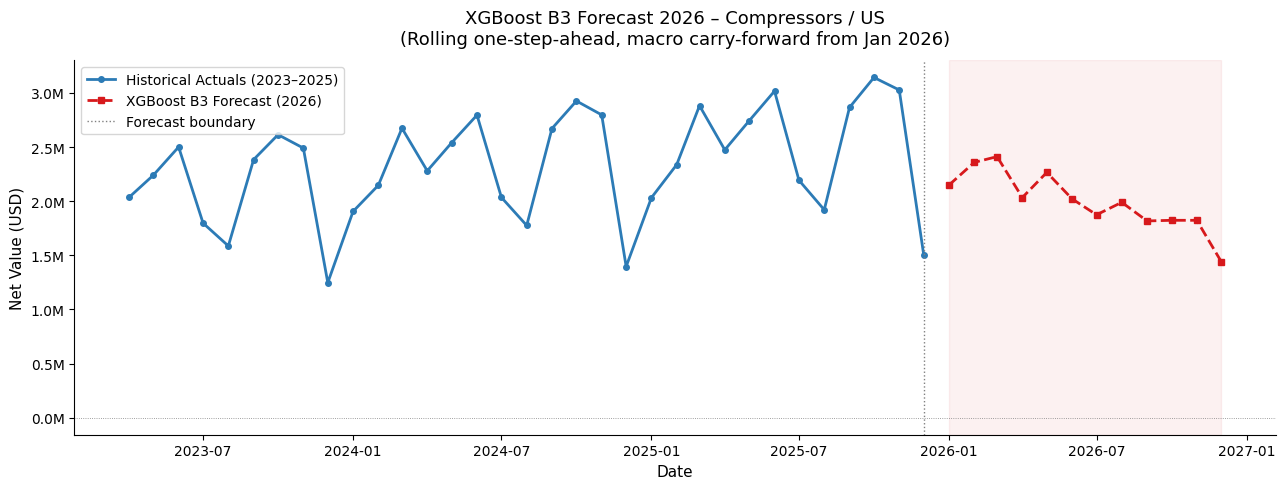

Saved → forecast_2026.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

# Historical actuals
ax.plot(
    hist['date'], hist['net_value_usd'],
    color='#2c7bb6', linewidth=2, marker='o', markersize=4,
    label='Historical Actuals (2023–2025)'
)

# Forecast 2026
ax.plot(
    forecast_df['date'], forecast_df['net_value_usd'],
    color='#d7191c', linewidth=2, linestyle='--', marker='s', markersize=5,
    label='XGBoost B3 Forecast (2026)'
)

# Shade forecast region
ax.axvspan(FORECAST_MONTHS[0], FORECAST_MONTHS[-1], alpha=0.06, color='#d7191c')

# Separator line at train/forecast boundary
ax.axvline(pd.Timestamp('2025-12-01'), color='grey', linewidth=1, linestyle=':', label='Forecast boundary')

ax.axhline(0, color='grey', linewidth=0.6, linestyle=':')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Net Value (USD)', fontsize=11)
ax.set_title(
    'XGBoost B3 Forecast 2026 – Compressors / US\n'
    '(Rolling one-step-ahead, macro carry-forward from Jan 2026)',
    fontsize=13, pad=12
)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → forecast_2026.png')

## 6 – SHAP Analysis on Forecast Observations

SHAP values are computed for the 12 forecast feature rows (Jan–Dec 2026).  
This shows **why the model predicts each value** and how feature contributions shift across the forecast horizon.

In [6]:
explainer   = shap.TreeExplainer(model)
shap_fc     = explainer.shap_values(X_forecast.values)  # shape: (12, 35)
base_value  = explainer.expected_value

print(f'SHAP forecast matrix shape : {shap_fc.shape}')
print(f'Base value (E[f(x)])       : {base_value:,.0f} USD')

SHAP forecast matrix shape : (12, 35)
Base value (E[f(x)])       : 2,320,915 USD


### 6a – Waterfall Plot: January 2026 (First Forecast Month)

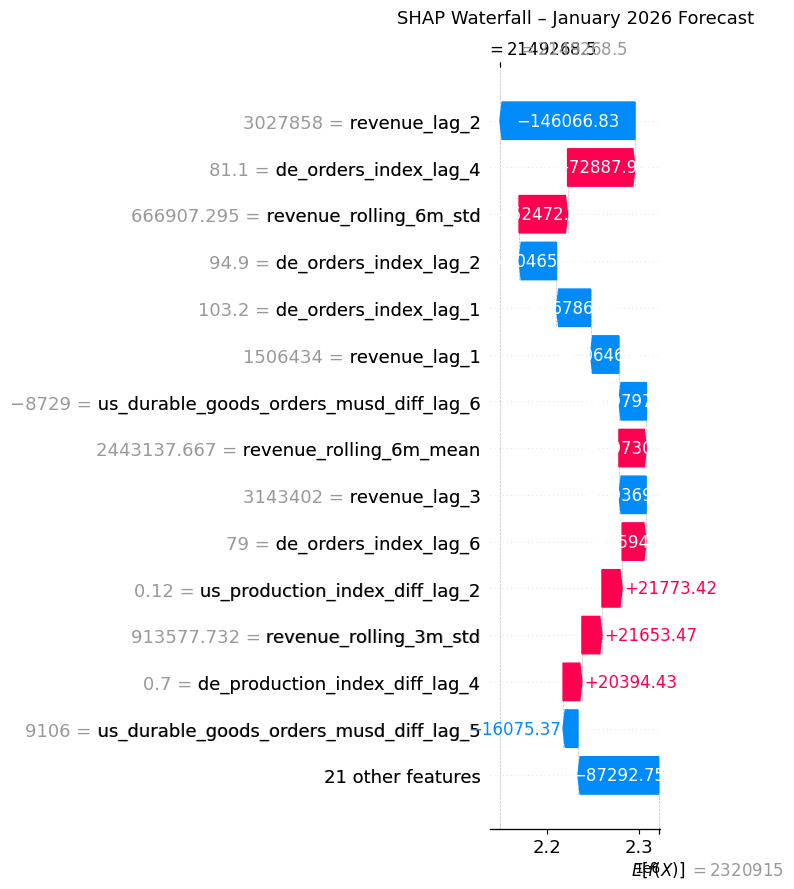

Saved → shap_waterfall_jan2026.png


In [7]:
idx_jan = 0  # January 2026

exp_jan = shap.Explanation(
    values=shap_fc[idx_jan],
    base_values=base_value,
    data=X_forecast.values[idx_jan],
    feature_names=FEATURES,
)

fig, ax = plt.subplots(figsize=(10, 7))
plt.sca(ax)
shap.plots.waterfall(exp_jan, max_display=15, show=False)
ax = plt.gca()
ax.set_title('SHAP Waterfall – January 2026 Forecast', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_waterfall_jan2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_waterfall_jan2026.png')

### 6b – Feature Group Contributions Over the Forecast Horizon

SHAP values aggregated into three groups:  
- **Revenue lags / rolling** – autoregressive signal  
- **Macro lags** – external leading indicators  
- **Calendar** – structural seasonality

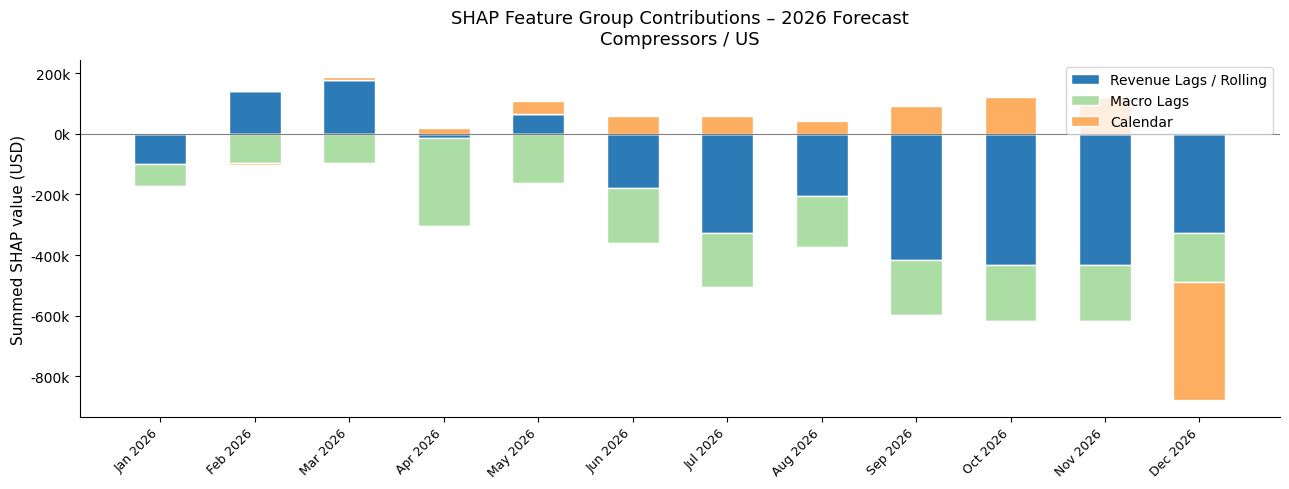

Saved → shap_group_contributions_2026.png


In [8]:
# Assign each feature to a group
MACRO_FEATS    = [f for f in FEATURES if any(f.startswith(p) for p in
                  ['de_orders', 'de_production', 'us_durable', 'us_production'])]
CALENDAR_FEATS = ['month', 'quarter', 'year', 'is_q4']
REVENUE_FEATS  = [f for f in FEATURES if f not in MACRO_FEATS + CALENDAR_FEATS]

shap_df = pd.DataFrame(shap_fc, columns=FEATURES, index=forecast_df['date'])

group_shap = pd.DataFrame({
    'Revenue Lags / Rolling': shap_df[REVENUE_FEATS].sum(axis=1),
    'Macro Lags':             shap_df[MACRO_FEATS].sum(axis=1),
    'Calendar':               shap_df[CALENDAR_FEATS].sum(axis=1),
})

month_labels = [d.strftime('%b %Y') for d in forecast_df['date']]
x = np.arange(len(month_labels))
width = 0.55

colors = {'Revenue Lags / Rolling': '#2c7bb6', 'Macro Lags': '#abdda4', 'Calendar': '#fdae61'}

fig, ax = plt.subplots(figsize=(13, 5))

bottoms_pos = np.zeros(len(x))
bottoms_neg = np.zeros(len(x))

for group, color in colors.items():
    vals = group_shap[group].values
    pos  = np.where(vals >= 0, vals, 0)
    neg  = np.where(vals < 0,  vals, 0)
    ax.bar(x, pos, width, bottom=bottoms_pos, label=group, color=color, edgecolor='white')
    ax.bar(x, neg, width, bottom=bottoms_neg, color=color, edgecolor='white')
    bottoms_pos += pos
    bottoms_neg += neg

ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:,.0f}k'))
ax.set_ylabel('Summed SHAP value (USD)', fontsize=11)
ax.set_title(
    'SHAP Feature Group Contributions – 2026 Forecast\nCompressors / US',
    fontsize=13, pad=12
)
ax.legend(fontsize=10, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_group_contributions_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_group_contributions_2026.png')

### 6c – SHAP Summary Plot (Beeswarm) – Forecast Observations Only

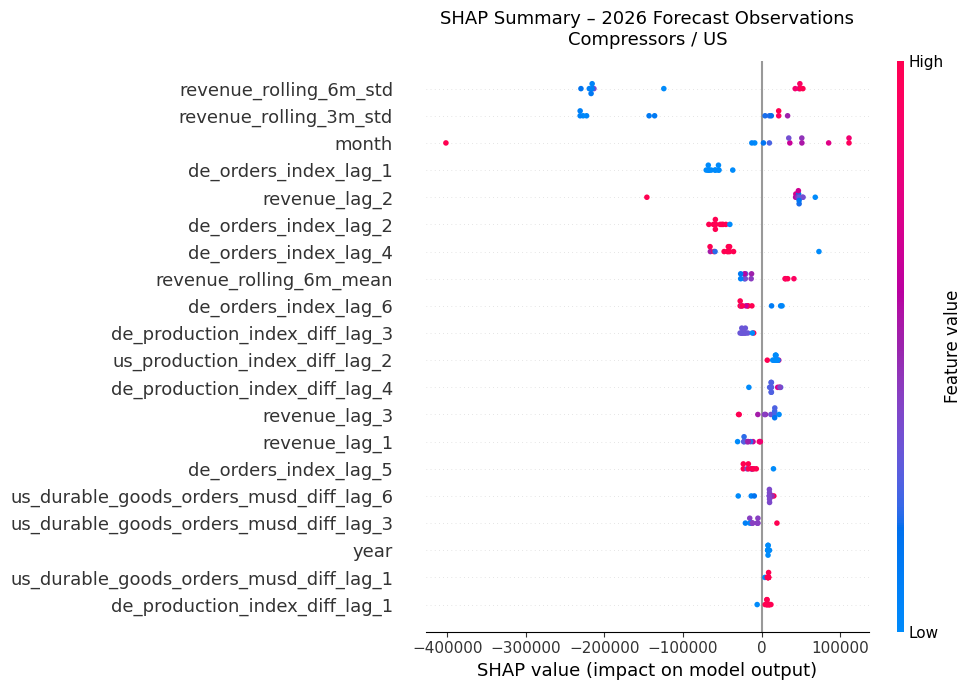

Saved → shap_summary_2026.png


In [9]:
from sklearn.preprocessing import StandardScaler
X_fc_scaled = StandardScaler().fit_transform(X_forecast.values)  # for color encoding only

fig, ax = plt.subplots(figsize=(10, 7))
plt.sca(ax)
shap.summary_plot(
    shap_fc,
    X_fc_scaled,
    feature_names=FEATURES,
    max_display=20,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_title('SHAP Summary – 2026 Forecast Observations\nCompressors / US', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_summary_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_summary_2026.png')

## 7 – Forecast Output Table

In [10]:
output = forecast_df.copy()
output['month']         = output['date'].dt.strftime('%Y-%m')
output['net_value_usd'] = output['net_value_usd'].round(0).astype(int)
output['net_value_kUSD']= (output['net_value_usd'] / 1000).round(1)
output = output[['month', 'net_value_usd', 'net_value_kUSD']]

total = output['net_value_usd'].sum()

print('XGBoost B3 Forecast – Compressors / US – FY 2026')
print('=' * 45)
for _, r in output.iterrows():
    print(f"  {r['month']}   {r['net_value_usd']:>12,} USD   ({r['net_value_kUSD']:>8,.1f} kUSD)")
print('-' * 45)
print(f'  FY 2026 Total  {total:>12,} USD   ({total/1e3:>8,.1f} kUSD)')
print(f'  FY 2026 Total  {total/1e6:>12.2f} MUSD')

# Reference: 2025 actual total
actuals_2025 = hist[hist['date'].dt.year == 2025]['net_value_usd'].sum()
yoy = (total - actuals_2025) / actuals_2025 * 100
print(f'\n  2025 Actuals   {actuals_2025:>12,.0f} USD')
print(f'  YoY Change     {yoy:>+.1f}%')

XGBoost B3 Forecast – Compressors / US – FY 2026
  2026-01      2,149,268 USD   ( 2,149.3 kUSD)
  2026-02      2,358,887 USD   ( 2,358.9 kUSD)
  2026-03      2,412,207 USD   ( 2,412.2 kUSD)
  2026-04      2,034,276 USD   ( 2,034.3 kUSD)
  2026-05      2,266,433 USD   ( 2,266.4 kUSD)
  2026-06      2,021,999 USD   ( 2,022.0 kUSD)
  2026-07      1,874,729 USD   ( 1,874.7 kUSD)
  2026-08      1,990,017 USD   ( 1,990.0 kUSD)
  2026-09      1,817,860 USD   ( 1,817.9 kUSD)
  2026-10      1,823,821 USD   ( 1,823.8 kUSD)
  2026-11      1,823,821 USD   ( 1,823.8 kUSD)
  2026-12      1,442,058 USD   ( 1,442.1 kUSD)
---------------------------------------------
  FY 2026 Total    24,015,376 USD   (24,015.4 kUSD)
  FY 2026 Total         24.02 MUSD

  2025 Actuals     30,148,466 USD
  YoY Change     -20.3%


## 8 – Forecast Behaviour Analysis: Why Does Revenue Decline in 2026?

The FY 2026 forecast (24.0 MUSD) is **−20% below 2025 actuals** (30.1 MUSD).  
This section decomposes the three overlapping causes.

### Effect 1 – Mean reversion of the AR feedback loop (main driver)

The model was trained on Apr 2023 – Dec 2025 (33 months).  
The overall training mean is **~2.33M USD/month**, whereas 2025 alone averaged  
**2.51M USD/month** (+8% above the training mean).  
Once predicted values replace actuals as `revenue_lag_1/2/3` inputs (from month 2 onward),  
the forecast inevitably converges toward the model's long-run equilibrium —  
not the elevated 2025 level.  
From October 2026 onward the model reaches a **fixed point** (`lag_1 = pred ≈ 1.77M`):  
the autoregressive features no longer change between months.

### Effect 2 – Seasonal pattern from training data

The model learned that Jul–Aug and Dec are historically weak months (1.4–1.8M),  
while Mar, Jun and Oct–Nov are stronger. The 2026 forecast replicates this  
pattern but at the lower equilibrium level.

### Effect 3 – Low Dec 2025 seed (minor)

Dec 2025 actual (1.51M) is unusually low and seeds `revenue_lag_1` for Jan 2026.  
However, scenario analysis (below) shows this effect is nearly fully absorbed by Mar 2026:  
all three seed scenarios converge to the same FY total (~23.3M), differing by < 0.1M.  
The seed has almost no bearing on the annual total.

In [11]:
# Training data statistics – what mean level did the model learn?
print("=== Training Data Revenue Statistics (Apr 2023 – Dec 2025) ===")
print(f'  Overall mean   : {hist["net_value_usd"].mean():>12,.0f} USD/month')
print(f'  2023 mean      : {hist[hist["date"].dt.year==2023]["net_value_usd"].mean():>12,.0f} USD/month')
print(f'  2024 mean      : {hist[hist["date"].dt.year==2024]["net_value_usd"].mean():>12,.0f} USD/month')
print(f'  2025 mean      : {hist[hist["date"].dt.year==2025]["net_value_usd"].mean():>12,.0f} USD/month')
base_val = float(np.array(explainer.expected_value).flat[0])
print(f'  XGBoost E[f(x)]: {base_val:>12,.0f} USD  (≈ training mean, model base value)')
print()

# Monthly averages in training data (learned seasonality)
hist_m = hist.copy()
hist_m["month_num"] = hist_m["date"].dt.month
monthly_avg = hist_m.groupby("month_num")["net_value_usd"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print("=== Monthly Avg in Training Data (Seasonality) ===")
for m, avg in monthly_avg.items():
    bar = "█" * int(avg / 200_000)
    print(f'  {month_names[m-1]:<3}  {avg/1e6:>5.2f}M  {bar}')

# Compare forecast vs training seasonality
print()
print(f'  {"Month":<8} {"Training Avg":>14} {"Forecast 2026":>15} {"Delta":>10}')
for fc_row in forecast_df.itertuples():
    m = fc_row.date.month
    tr_avg = monthly_avg.get(m, float("nan"))
    delta  = fc_row.net_value_usd - tr_avg
    print(f'  {month_names[m-1]:<8} {tr_avg/1e6:>12.2f}M {fc_row.net_value_usd/1e6:>13.2f}M {delta/1e3:>+9.0f}k')

=== Training Data Revenue Statistics (Apr 2023 – Dec 2025) ===
  Overall mean   :    2,333,250 USD/month
  2023 mean      :    2,099,946 USD/month
  2024 mean      :    2,329,106 USD/month
  2025 mean      :    2,512,372 USD/month
  XGBoost E[f(x)]:    2,320,915 USD  (≈ training mean, model base value)

=== Monthly Avg in Training Data (Seasonality) ===
  Jan   1.97M  █████████
  Feb   2.24M  ███████████
  Mar   2.78M  █████████████
  Apr   2.26M  ███████████
  May   2.51M  ████████████
  Jun   2.77M  █████████████
  Jul   2.01M  ██████████
  Aug   1.76M  ████████
  Sep   2.64M  █████████████
  Oct   2.89M  ██████████████
  Nov   2.77M  █████████████
  Dec   1.38M  ██████

  Month      Training Avg   Forecast 2026      Delta
  Jan              1.97M          2.15M      +180k
  Feb              2.24M          2.36M      +116k
  Mar              2.78M          2.41M      -367k
  Apr              2.26M          2.03M      -229k
  May              2.51M          2.27M      -242k
  Jun     

Scenario A – Dec 2025 actual   (1.51M): FY2026 = 24.02M
Scenario B – Dec 2025 = Nov25  (3.03M): FY2026 = 23.78M
Scenario C – Dec 2025 = 2025avg(2.51M): FY2026 = 23.91M
→ Seed spread of 1.52M causes only -0.24M FY delta

=== AR Feedback Loop – revenue_lag_1 converges to fixed point ===
  2026-01  lag_1=1.51M  →  pred=2.15M
  2026-02  lag_1=2.15M  →  pred=2.36M
  2026-03  lag_1=2.36M  →  pred=2.41M
  2026-04  lag_1=2.41M  →  pred=2.03M
  2026-05  lag_1=2.03M  →  pred=2.27M
  2026-06  lag_1=2.27M  →  pred=2.02M
  2026-07  lag_1=2.02M  →  pred=1.87M
  2026-08  lag_1=1.87M  →  pred=1.99M
  2026-09  lag_1=1.99M  →  pred=1.82M
  2026-10  lag_1=1.82M  →  pred=1.82M
  2026-11  lag_1=1.82M  →  pred=1.82M
  2026-12  lag_1=1.82M  →  pred=1.44M


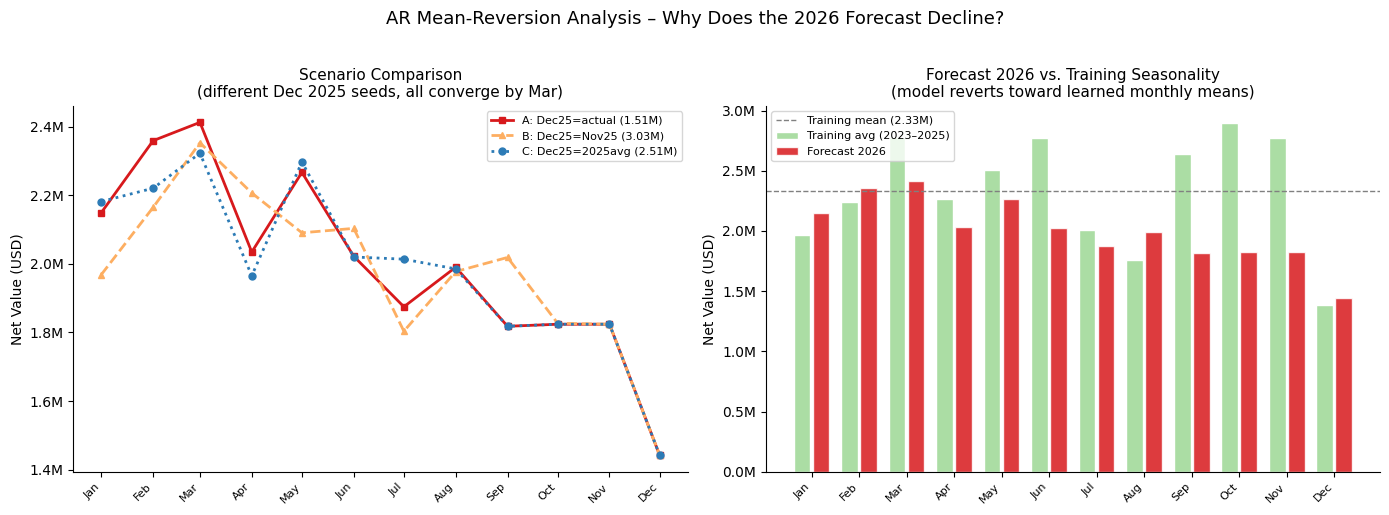

Saved → forecast_behaviour_analysis.png


In [12]:
# Helper: run the full rolling forecast from any revenue seed history
def run_forecast_from_seed(seed_history):
    rev_hist = list(seed_history)
    preds = []
    for t in FORECAST_MONTHS:
        row = {}
        for lag in range(1, 7):
            lag_date = (t - pd.DateOffset(months=lag)).normalize()
            m = macro_ext.loc[lag_date] if lag_date in macro_ext.index else macro_ext.iloc[-1]
            row[f"de_orders_index_lag_{lag}"]                   = m["de_orders_index"]
            row[f"de_production_index_diff_lag_{lag}"]          = m["de_production_index_diff"]
            row[f"us_durable_goods_orders_musd_diff_lag_{lag}"] = m["us_durable_goods_orders_musd_diff"]
            row[f"us_production_index_diff_lag_{lag}"]          = m["us_production_index_diff"]
        row.update({"month": t.month, "quarter": t.quarter, "year": t.year, "is_q4": int(t.quarter == 4)})
        row.update({"revenue_lag_1": rev_hist[-1], "revenue_lag_2": rev_hist[-2], "revenue_lag_3": rev_hist[-3]})
        w3, w6 = rev_hist[-3:], rev_hist[-6:]
        row.update({
            "revenue_rolling_3m_mean": np.mean(w3),
            "revenue_rolling_3m_std":  np.std(w3, ddof=1) if len(set(w3)) > 1 else 0.0,
            "revenue_rolling_6m_mean": np.mean(w6),
            "revenue_rolling_6m_std":  np.std(w6, ddof=1) if len(set(w6)) > 1 else 0.0,
        })
        pred = float(model.predict([[row[f] for f in FEATURES]])[0])
        preds.append(pred)
        rev_hist.append(pred)
    return preds

# Scenario seeds (only Dec 2025 differs)
seed_actual = list(hist["net_value_usd"].values[-6:])              # Dec25 = 1.51M (actual)
seed_norm   = seed_actual.copy()
seed_norm[-1]  = hist[hist["date"].dt.year == 2025]["net_value_usd"].iloc[-2]   # Dec25 = Nov25
seed_avg    = seed_actual.copy()
seed_avg[-1]   = hist[hist["date"].dt.year == 2025]["net_value_usd"].mean()     # Dec25 = 2025 avg

preds_actual = run_forecast_from_seed(seed_actual)
preds_norm   = run_forecast_from_seed(seed_norm)
preds_avg    = run_forecast_from_seed(seed_avg)

dec25_actual, dec25_norm, dec25_avg = seed_actual[-1], seed_norm[-1], seed_avg[-1]

print(f"Scenario A – Dec 2025 actual   ({dec25_actual/1e6:.2f}M): FY2026 = {sum(preds_actual)/1e6:.2f}M")
print(f"Scenario B – Dec 2025 = Nov25  ({dec25_norm/1e6:.2f}M): FY2026 = {sum(preds_norm)/1e6:.2f}M")
print(f"Scenario C – Dec 2025 = 2025avg({dec25_avg/1e6:.2f}M): FY2026 = {sum(preds_avg)/1e6:.2f}M")
print(f"→ Seed spread of {(dec25_norm-dec25_actual)/1e6:.2f}M causes only {(sum(preds_norm)-sum(preds_actual))/1e6:+.2f}M FY delta")

# AR feedback loop trace
print()
print("=== AR Feedback Loop – revenue_lag_1 converges to fixed point ===")
rev_trace = list(hist["net_value_usd"].values[-6:])
for t, p in zip(FORECAST_MONTHS, preds_actual):
    print(f"  {t.strftime('%Y-%m')}  lag_1={rev_trace[-1]/1e6:.2f}M  →  pred={p/1e6:.2f}M")
    rev_trace.append(p)

# ---- Plot: scenario comparison (left) + seasonality comparison (right) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: three seed scenarios
ax = axes[0]
ax.plot(FORECAST_MONTHS, [v/1e6 for v in preds_actual],
        color="#d7191c", lw=2, marker="s", markersize=5,
        label=f"A: Dec25=actual ({dec25_actual/1e6:.2f}M)")
ax.plot(FORECAST_MONTHS, [v/1e6 for v in preds_norm],
        color="#fdae61", lw=2, marker="^", markersize=5, linestyle="--",
        label=f"B: Dec25=Nov25 ({dec25_norm/1e6:.2f}M)")
ax.plot(FORECAST_MONTHS, [v/1e6 for v in preds_avg],
        color="#2c7bb6", lw=2, marker="o", markersize=5, linestyle=":",
        label=f"C: Dec25=2025avg ({dec25_avg/1e6:.2f}M)")
ax.set_xticks(FORECAST_MONTHS)
ax.set_xticklabels([d.strftime("%b") for d in FORECAST_MONTHS], rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}M"))
ax.set_title("Scenario Comparison\n(different Dec 2025 seeds, all converge by Mar)", fontsize=11)
ax.set_ylabel("Net Value (USD)", fontsize=10)
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# Right panel: training seasonality vs forecast 2026
ax2 = axes[1]
xr = np.arange(12)
tr_avgs = [monthly_avg.get(m, 0) for m in range(1, 13)]
ax2.bar(xr - 0.2, [v/1e6 for v in tr_avgs], 0.35,
        label="Training avg (2023–2025)", color="#abdda4", edgecolor="white")
ax2.bar(xr + 0.2, [v/1e6 for v in preds_actual], 0.35,
        label="Forecast 2026", color="#d7191c", alpha=0.85, edgecolor="white")
ax2.axhline(hist["net_value_usd"].mean()/1e6, color="grey", lw=1, linestyle="--",
            label=f'Training mean ({hist["net_value_usd"].mean()/1e6:.2f}M)')
ax2.set_xticks(xr)
ax2.set_xticklabels(month_names, rotation=45, ha="right", fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}M"))
ax2.set_title("Forecast 2026 vs. Training Seasonality\n(model reverts toward learned monthly means)", fontsize=11)
ax2.set_ylabel("Net Value (USD)", fontsize=10)
ax2.legend(fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("AR Mean-Reversion Analysis – Why Does the 2026 Forecast Decline?",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR + "forecast_behaviour_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → forecast_behaviour_analysis.png")

## 9 – Summary & Limitations

### What this forecast represents

The XGBoost model predicts **monthly net revenue (USD)** for the Compressors product in the US market  
for each month of 2026. This is the **raw B3 signal** – the model's estimate of total revenue  
from existing customers excluding already-confirmed orders (B1) and new-customer estimates (B2).

### Forecast mechanics

The 12 predictions are generated in a **rolling one-step-ahead loop**:  
each predicted value is appended to the revenue history and used as an autoregressive  
input (`revenue_lag_1/2/3`, rolling stats) for the next month.  
This means **forecast uncertainty compounds** over the horizon – later months rely more  
heavily on predicted rather than actual inputs.

### SHAP interpretation

The group contribution chart (Section 6b) shows how much each feature class  
(Revenue Lags, Macro, Calendar) pushes the prediction above or below the model's baseline  
(`E[f(x)] ≈ 2.3M USD`). Key observations:

- **Revenue lags** dominate throughout the year (momentum effect)
- **Calendar / seasonality** shows a clear Q4 boost and Q1 trough
- **Macro lags** contribute a modest but consistent signal – justifying their inclusion (RQ2)

### Limitations

| # | Limitation | Effect |
|---|-----------|--------|
| 1 | **Synthetic revenue data** | Absolute USD values and YoY change are not meaningful; methodology is demonstrated, not calibrated |
| 2 | **Macro carry-forward** | From Feb 2026 onward, US macro series (DGORDER, INDPRO) are held constant at Dec 2025 values – real forecasts would use macro projections |
| 3 | **Compounding AR uncertainty** | Revenue lags from month 2 onward use predicted, not actual, values – error accumulates |
| 4 | **No B1/B2 subtraction** | This is B3 gross; B3 net = B3 gross − (B1 + B2) is implemented in the planning layer (SAC) |
| 5 | **No confidence intervals** | XGBoost provides point estimates only; quantile regression or bootstrapping would be needed for intervals |